#Análisis Exploratorio de Datos (EDA)  
## Proyecto Lyapunov IRAG — Detección de comportamiento epidémico inusual

Este cuaderno desarrolla la fase de **Análisis Exploratorio de Datos (EDA)** y **comprensión del conjunto de datos** utilizado en el proyecto Lyapunov IRAG.

Los objetivos principales de este notebook son:

- Describir la estructura del conjunto de datos (dimensiones, tipos de variables).
- Verificar la calidad de los datos (valores faltantes, rangos, consistencia).
- Explorar de forma descriptiva los principales indicadores de IRAG (hospitalización, UCI, mortalidad y consultas).
- Analizar la distribución de la **variable objetivo (`target`)**, que indica si en una semana se observa un comportamiento de IRAG **normal (0)** o **inusual (1)**.
- Producir insumos para la fase posterior de **modelado supervisado**.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

# Cargar dataset limpio generado por DVC
df = pd.read_csv("../data/clean/train.csv")

df.head()

,anio,semana,HOSPITALIZACION IRAG MENOR 1 AÑO,HOSPITALIZACION IRAG 1 AÑO,HOSPITALIZACION IRAG 2 A 4 AÑOS,HOSPITALIZACION IRAG 5 A 19 AÑOS,HOSPITALIZACION IRAG 20 A 39 AÑOS,HOSPITALIZACION IRAG 40 A 59 AÑOS,HOSPITALIZACION IRAG MAYOR 60 AÑOS,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,TOTAL CAUSAS HOSPITALIZACIONES MENOR 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 2 A 4 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 5 A 19 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 20 A 39 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 40 A 59 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES MAYOR 60 AÑOS,TOTAL HOSPITALIZACIONES POR TODAS LAS CAUSAS,HOSPITALIZACIONES EN UCI POR IRAG MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS,TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MAYOR 60 AÑOS,TOTAL TODAS LAS HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS,MUERTES POR IRAG MENOR 1 AÑO,MUERTES POR IRAG 1 AÑO,MUERTES POR IRAG 2 A 4 AÑOS,MUERTES POR IRAG 5 A 19 AÑOS,MUERTES POR IRAG 20 A 39 AÑOS,MUERTES POR IRAG 40 A 59 AÑOS,MUERTES POR IRAG MAYOR 60 AÑOS,TOTAL DE MUERTES POR IRAG,TODAS LAS CAUSAS DE MUERTE MENOR 1 AÑO,TODAS LAS CAUSAS DE MUERTE 1 AÑO,TODAS LAS CAUSAS DE MUERTE 2 A 4 AÑOS,TODAS LAS CAUSAS DE MUERTE 5 A 19 AÑOS,TODAS LAS CAUSAS DE MUERTE 20 A 39 AÑOS,TODAS LAS CAUSAS DE MUERTE 40 A 59 AÑOS,TODAS LAS CAUSAS DE MUERTE MAYOR 60 AÑOS,TOTAL DE MUERTES POR TODAS LAS CAUSAS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MENOR 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 2 A 4 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 5 A 19 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 20 A 39 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 40 A 59 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MENOR 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 2 A 4 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 5 A 19 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 20 A 39 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 40 A 59 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG,prop_hosp_irag,prop_uci_irag,prop_muertes_irag,prop_consultas_irag,I_t_minus_1,growth_rate,target
0,2012,2,7,3,9,3,0,1,0,23,6,2,8,0,0,0,0,16,6,2,8,0,0,0,0,16,2,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,23,49,88,81,48,11,306,23,47,137,221,250,182,160,1020,1.352941,4.000000,0.000000,0.299706,0.000000,1.352941,1
1,2012,3,3,3,5,5,0,1,3,20,4,3,6,18,30,9,97,167,4,3,6,18,30,9,97,167,4,0,0,0,2,5,21,32,0,0,0,0,0,1,2,3,1,0,0,0,0,2,10,13,12,26,25,54,104,56,41,318,77,101,226,583,1044,951,1082,4064,0.119048,5.060606,0.214286,0.078229,1.352941,-0.524405,0
2,2012,4,4,4,4,7,1,1,19,40,16,23,28,67,166,115,149,564,16,23,28,67,166,115,149,564,17,2,1,2,0,3,18,43,0,0,0,0,0,0,2,2,1,0,0,1,0,2,19,23,26,50,40,106,149,94,56,521,166,237,493,1241,2079,1881,1695,7792,0.070796,12.818182,0.083333,0.066855,0.119048,-0.043118,0
3,2012,5,3,1,1,3,15,26,13,62,2,3,3,21,72,62,94,257,2,3,3,21,72,62,94,257,10,0,0,2,5,2,17,36,0,0,0,0,0,0,0,0,1,0,0,1,0,2,7,1

## 1. Carga del dataset e información general

En esta sección se carga el dataset limpio generado por el pipeline (etapas de`clean_data` y `prepare_data`) y se revisa su estructura básica:

- Número de filas (registros semanales por año).
- Número de columnas (indicadores de IRAG y proporciones).
- Tipos de datos de cada variable.
- Presencia de valores nulos detectados por `df.info()`.

Esto permite comprobar que la fase de limpieza se ejecutó correctamente y que el dataset está en condiciones de ser analizado y utilizado para modelado.

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 73 columns):
 #   Column                                                                                                           Non-Null Count  Dtype  
---  ------                                                                                                           --------------  -----  
 0   anio                                                                                                             564 non-null    int64  
 1   semana                                                                                                           564 non-null    int64  
 2   HOSPITALIZACION IRAG MENOR 1 AÑO                                                                                 564 non-null    int64  
 3   HOSPITALIZACION IRAG 1 AÑO                                                                                       564 non-null    int64  
 4   HOSPITALIZACION IRAG 2 A 4 AÑOS       

## 2. Estadísticas descriptivas de las variables numéricas

A continuación se calculan estadísticas descriptivas básicas
(media, desviación estándar, mínimos, máximos y cuartiles) para las variables
numéricas del conjunto de datos.

Estas estadísticas permiten:

- Identificar rangos típicos de hospitalización, UCI, mortalidad y consultas.
- Detectar posibles **valores atípicos** (por ejemplo, semanas con conteos extremadamente altos o bajos).
- Reconocer variables con muy poca variabilidad, que podrían tener bajo poder explicativo en los modelos.

In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
anio,564.0,2016.929078,3.121336,2012.000000,2014.000000,2017.000000,2020.000000,2022.000000
semana,564.0,26.296099,14.921556,1.000000,13.000000,26.000000,39.000000,53.000000
HOSPITALIZACION IRAG MENOR 1 AÑO,564.0,22.427305,18.689480,0.000000,6.000000,21.000000,36.000000,129.000000
HOSPITALIZACION IRAG 1 AÑO,564.0,8.028369,4.993343,0.000000,5.000000,7.000000,11.000000,41.000000
HOSPITALIZACION IRAG 2 A 4 AÑOS,564.0,12.987589,9.411164,0.000000,6.000000,12.000000,19.000000,82.000000
...,...,...,...,...,...,...,...,...
prop_muertes_irag,564.0,0.110915,0.164356,0.000000,0.000000,0.050000,0.142857,1.280000
prop_consultas_irag,564.0,0.090768,0.042057,0.024299,0.066406,0.085541,0.106460,0.583576
I_t_minus_1,564.0,0.185338,0.165755,0.000000,0.073565,0.197703,0.256901,3.003546
growth_rate,564.0,0.006814,0.147860,-0.605256,-0.023980,0.001385,0.025096,2.729071


## 3. Análisis de valores faltantes

La presencia de valores faltantes puede afectar:

- El entrenamiento de los modelos,
- El cálculo de métricas,
- Y la interpretación epidemiológica de los resultados.

Por eso se calcula, para cada columna, el número de valores `NaN`.

En función del resultado de `df.isna().sum()` se decidirá, en el notebook de preparación de datos, si es necesario:

- Imputar valores,
- Eliminar registros,
- O descartar variables con demasiados faltantes.

In [44]:
df.isna().sum()

anio                                0
semana                              0
HOSPITALIZACION IRAG MENOR 1 AÑO    0
HOSPITALIZACION IRAG 1 AÑO          0
HOSPITALIZACION IRAG 2 A 4 AÑOS     0
                                   ..
prop_muertes_irag                   0
prop_consultas_irag                 0
I_t_minus_1                         0
growth_rate                         0
target                              0
Length: 73, dtype: int64

## 4. Distribución de la variable objetivo (`target`)

La variable `target` codifica el comportamiento semanal del IRAG:

- `0` → semana con comportamiento **dentro de lo esperado** (normal).
- `1` → semana con comportamiento **inusual** o potencialmente epidémico.

Es fundamental revisar su distribución porque:

- Un fuerte desbalance entre clases puede generar modelos con alta exactitud pero baja capacidad para detectar semanas inusuales.
- Será necesario considerar técnicas específicas (ajuste de pesos, métricas adecuadas, etc.) si el desbalance es importante.

El siguiente gráfico y conteo de frecuencias permiten visualizar dicha distribución.
 

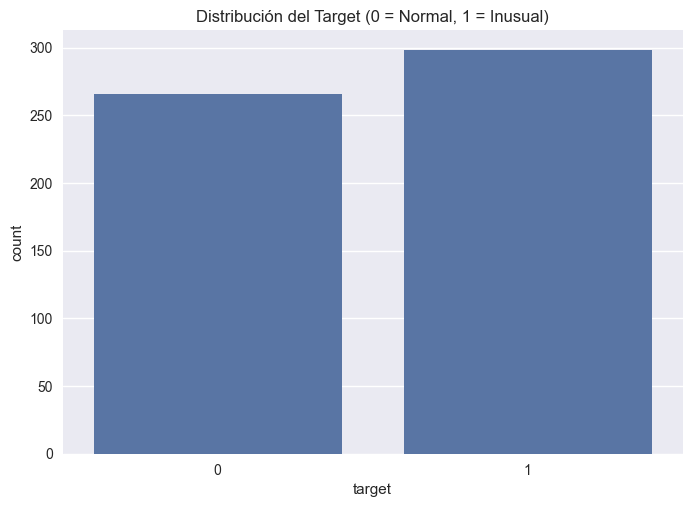

target
1    0.528369
0    0.471631
Name: proportion, dtype: float64

In [45]:
sns.countplot(x=df["target"])
plt.title("Distribución del Target (0 = Normal, 1 = Inusual)")
plt.show()

df["target"].value_counts(normalize=True)

## 5. Matriz de correlación entre variables numéricas

Para comprender mejor la relación entre los distintos indicadores de IRAG, se calcula una matriz de correlación de Pearson.

Este análisis permite:

- Detectar **grupos de variables altamente correlacionadas** (por ejemplo, hospitalizaciones totales, UCI y muertes).
- Identificar redundancias que podrían simplificar el modelo.
- Reconocer variables con correlación relevante respecto al `target` (lo que motiva su uso en el modelado supervisado).

La matriz se visualiza mediante un mapa de calor.

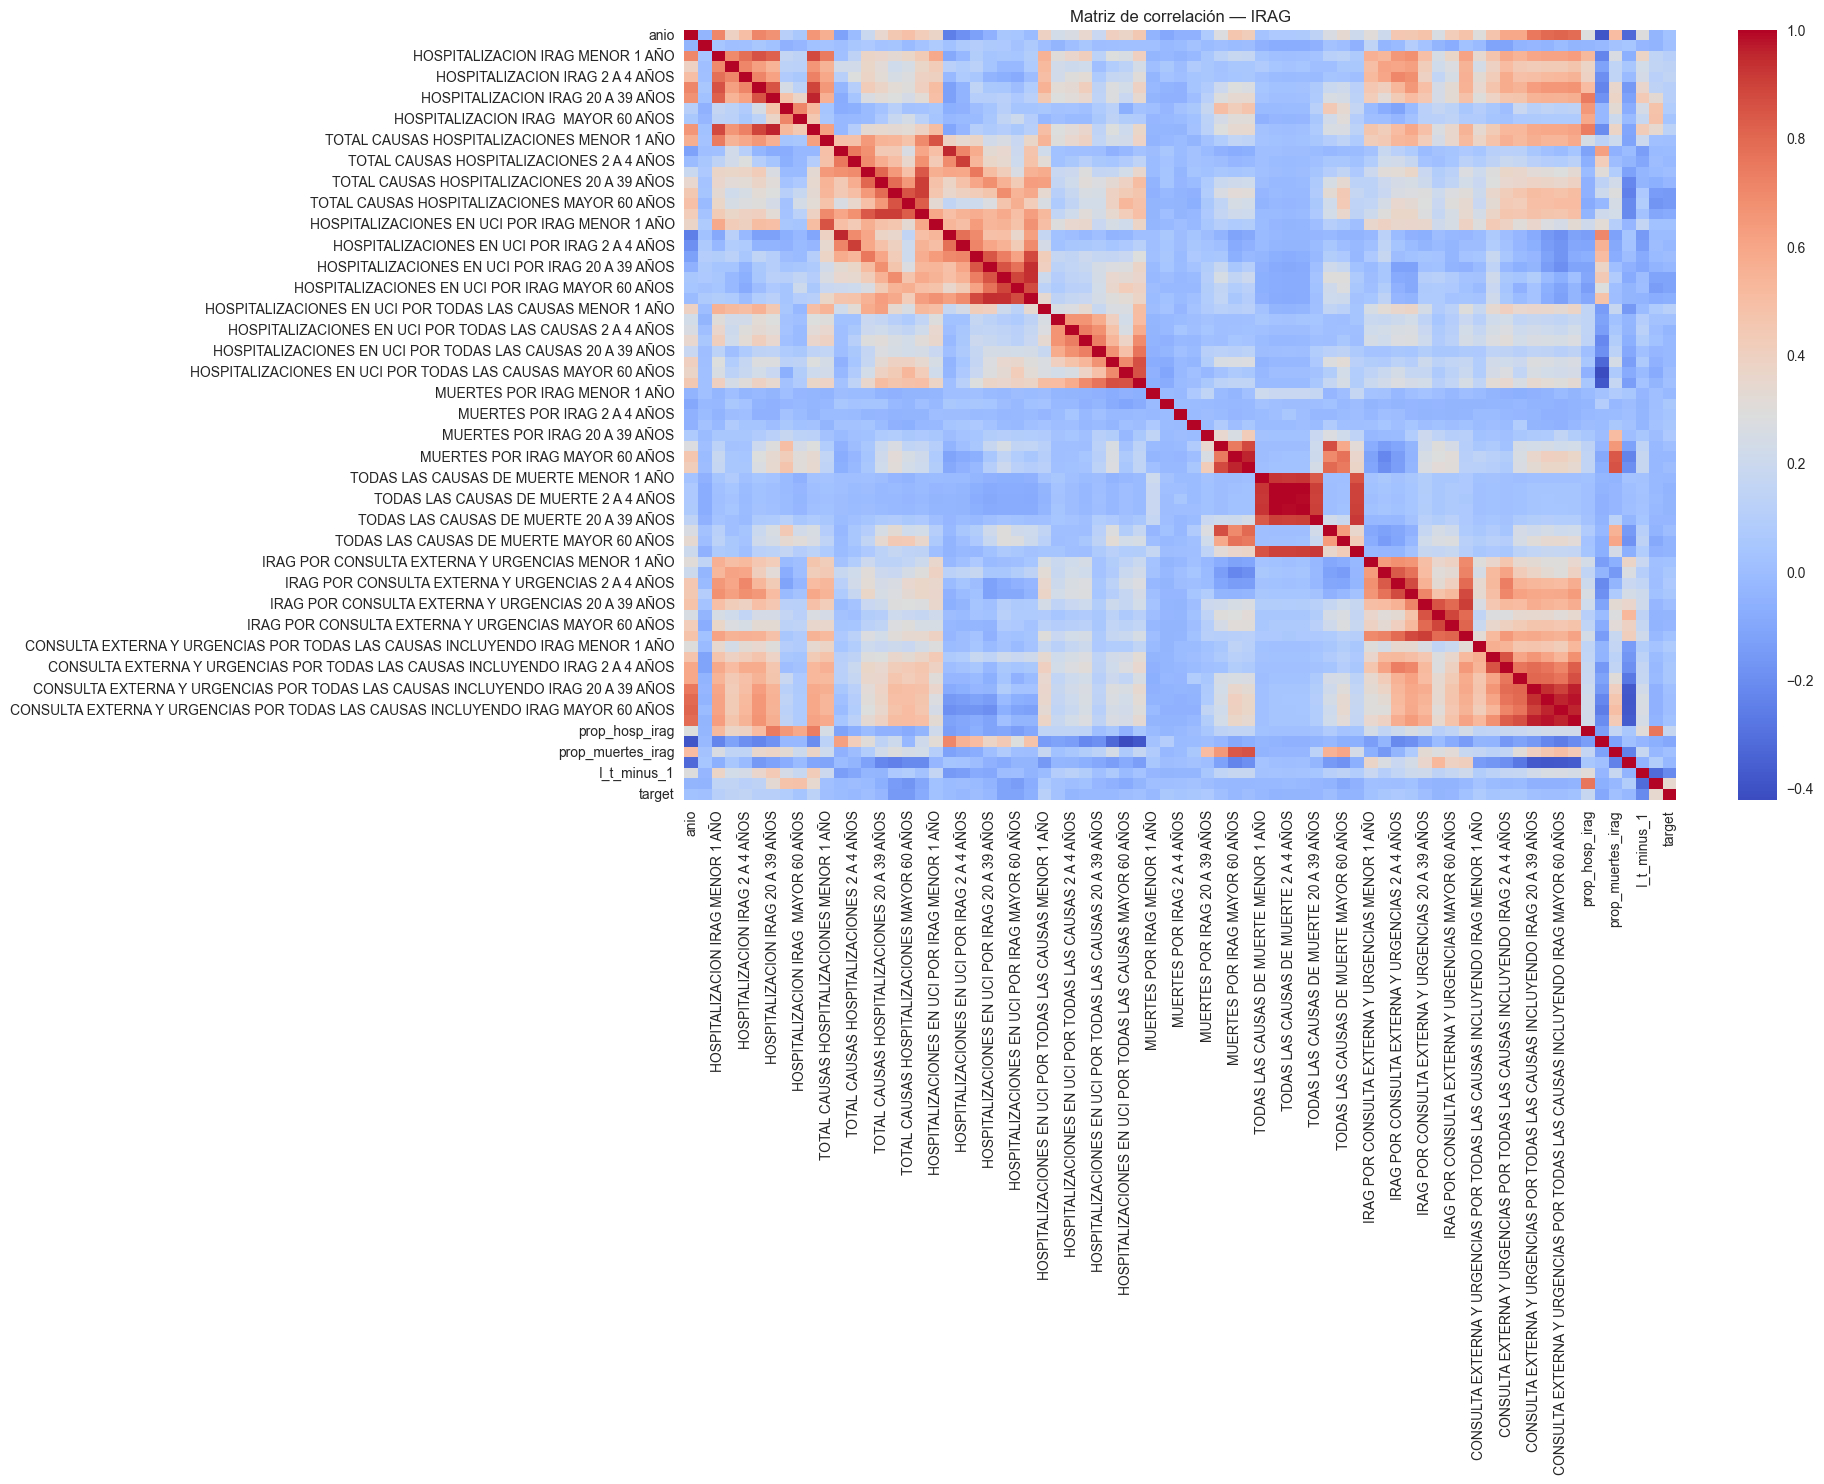

In [46]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación — IRAG")
plt.show()

## 6. Tendencias temporales del IRAG

Dado que el IRAG es un fenómeno **altamente estacional**, es importante analizar su comportamiento en el tiempo.

En esta sección se observa la evolución de:

- Las **hospitalizaciones por IRAG** a lo largo de las semanas epidemiológicas.
- La comparación entre **diferentes años**, para identificar:
  - picos recurrentes (por ejemplo, temporadas de mayor circulación viral),
  - años con comportamiento atípico,
  - posibles desplazamientos en el pico estacional.

Este análisis temporal es clave para:
- contextualizar las semanas marcadas como `target = 1`,
- y justificar el uso de modelos que incorporen información histórica o rezagos (como la variable `I_t_minus_1` y la tasa de crecimiento `growth_rate` que ya están presentes en el dataset.

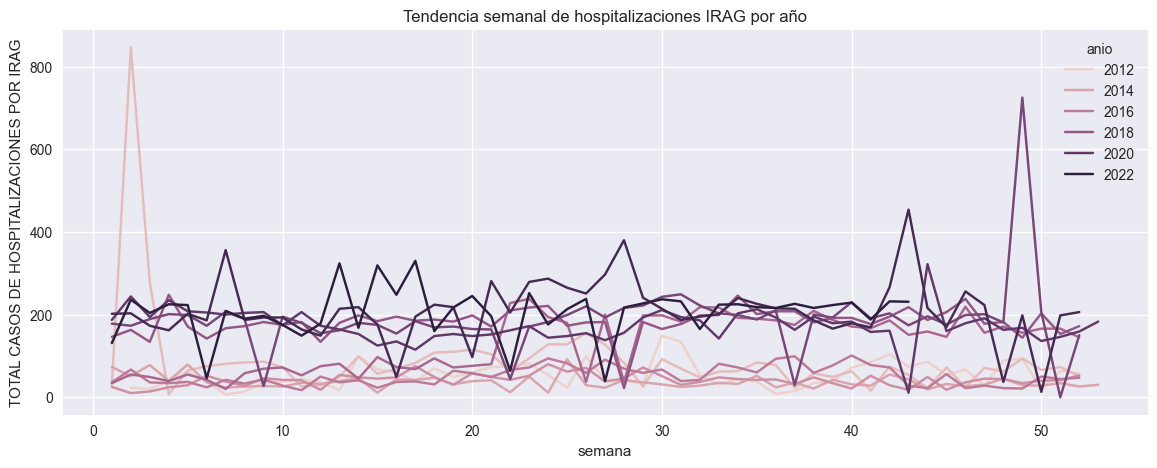

In [47]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x="semana", y="TOTAL CASOS DE HOSPITALIZACIONES POR IRAG", hue="anio")
plt.title("Tendencia semanal de hospitalizaciones IRAG por año")
plt.show()

## 7. Distribuciones de variables clave

Además del análisis temporal, es necesario revisar la **forma de la distribución** de las principales variables de carga de enfermedad:

- `TOTAL CASOS DE HOSPITALIZACIONES POR IRAG`
- `TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG`
- `TOTAL DE MUERTES POR IRAG`
- `TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS`

El objetivo de esta sección es:

- Identificar **sesgos** (distribuciones muy asimétricas hacia la derecha, típicas de conteos de eventos).
- Detectar la presencia de **colas largas** o valores extremos que puedan requerir transformaciones (por ejemplo, logaritmo) antes del modelado.
- Observar si la mayoría de las semanas se concentran en niveles bajos o moderados de IRAG, con pocas semanas extremadamente altas.

Estos hallazgos ayudan a decidir: qué transformaciones aplicar, qué métricas utilizar, y cómo interpretar los coeficientes de los modelos posteriores.

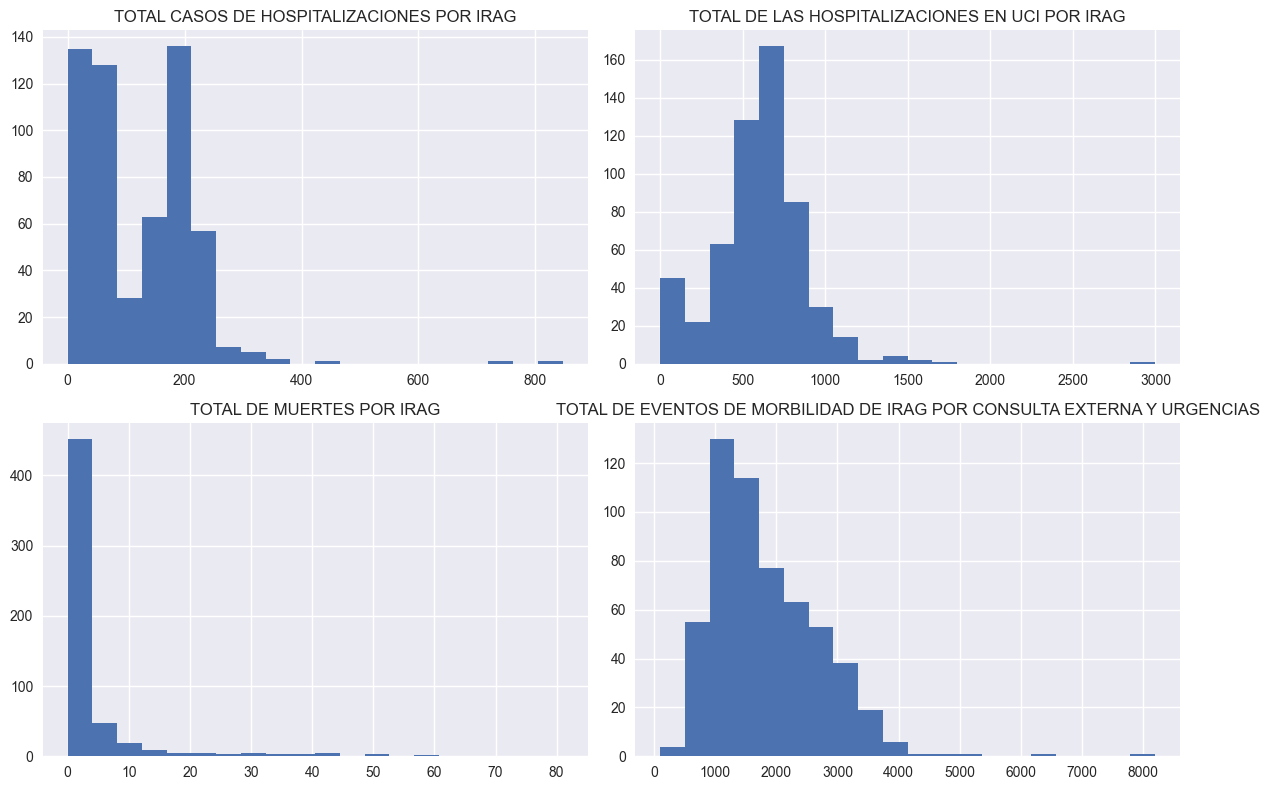

In [48]:
columnas_clave = [
    "TOTAL CASOS DE HOSPITALIZACIONES POR IRAG",
    "TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG",
    "TOTAL DE MUERTES POR IRAG",
    "TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS"
]

df[columnas_clave].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

## 8. Conclusiones del EDA

A partir del análisis exploratorio realizado se puede resumir que:

- El dataset presenta una estructura consistente y adecuada para el modelado supervisado (número de registros, tipos de variables y ausencia/manejo de valores faltantes).
- Las variables relacionadas con hospitalizaciones, UCI, mortalidad y consultas muestran patrones coherentes con la dinámica de IRAG y presentan variabilidad suficiente para ser útiles en un modelo predictivo.
- La variable objetivo (`target`) presenta un cierto grado de desbalance entre clases, lo cual se deberá tener en cuenta al seleccionar las métricas y los algoritmos de clasificación.
- Se observan relaciones importantes entre varios indicadores (según la matriz de correlación), lo que sugiere posibles grupos de variables redundantes y la necesidad de analizar su contribución durante el modelado.

Este notebook deja documentada la comprensión del conjunto de datos y sirve como base para el siguiente paso del proyecto: la **preparación de datos y entrenamiento de modelos de clasificación para detectar semanas con comportamiento inusual de IRAG.**
